In [39]:
# !pip install opencv-python tensorflow scikit-learn

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.cluster import KMeans
from tensorflow.keras.layers import (
    ConvLSTM2D, Conv2D, Input,
    MaxPooling2D, UpSampling2D, Concatenate
)
from tensorflow.keras.models import Model

In [40]:
IMG_SIZE = (128, 128)
SEQ_LENGTH = 2   # 🔥 smaller because dataset is small
NUM_CLASSES = 5
DATASET_PATH = "flood_dataset/"

In [41]:
def load_raw_images(folder):
    images = []
    
    files = sorted(os.listdir(folder))
    
    for file in files:
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        
        path = os.path.join(folder, file)
        
        img = cv2.imread(path)
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        
        images.append(img)
    
    return np.array(images)

raw_images = load_raw_images(DATASET_PATH)
print("Raw images:", raw_images.shape)

Raw images: (9, 128, 128, 3)


In [42]:
def augment_images(images):
    aug = []
    
    for img in images:
        aug.append(img)
        aug.append(cv2.flip(img, 1))  # horizontal
        aug.append(cv2.flip(img, 0))  # vertical
        aug.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    
    return np.array(aug)

aug_images = augment_images(raw_images)
print("Augmented:", aug_images.shape)

Augmented: (36, 128, 128, 3)


In [43]:
def fit_kmeans_global(images, k=5):
    pixels = images.reshape(-1, 3)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixels)
    
    return kmeans

kmeans_model = fit_kmeans_global(aug_images, k=NUM_CLASSES)

In [44]:
def image_to_classes(image, kmeans):
    h, w, _ = image.shape
    
    pixels = image.reshape(-1, 3)
    labels = kmeans.predict(pixels)
    
    return labels.reshape(h, w)

X_data = []
y_data = []

for img in aug_images:
    label = image_to_classes(img, kmeans_model)
    
    X_data.append(img / 255.0)
    y_data.append(label)

X_data = np.array(X_data)
y_data = np.array(y_data)

print("Classes:", np.unique(y_data))

Classes: [0 1 2 3 4]


In [45]:
def create_sequences(images, labels, seq_length):
    X, y = [], []
    
    for i in range(len(images) - seq_length):
        X.append(images[i:i+seq_length])
        y.append(labels[i+seq_length])
    
    return np.array(X), np.array(y)

X, y = create_sequences(X_data, y_data, SEQ_LENGTH)

In [46]:
y = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

In [47]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [48]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2. * intersection + smooth) / (union + smooth)

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return ce + dice_loss(y_true, y_pred)

In [49]:
inputs = Input(shape=(SEQ_LENGTH, 128, 128, 3))

x = ConvLSTM2D(16, (3,3), padding='same', return_sequences=False, activation='relu')(inputs)

c1 = Conv2D(32, (3,3), activation='relu', padding='same')(x)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(64, (3,3), activation='relu', padding='same')(p1)

u1 = UpSampling2D((2,2))(c2)
u1 = Concatenate()([u1, c1])

c3 = Conv2D(32, (3,3), activation='relu', padding='same')(u1)

outputs = Conv2D(NUM_CLASSES, (1,1), activation='softmax')(c3)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss=combined_loss,
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 2, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_3       │ (None, 128, 128,  │     11,008 │ input_layer_3[0]… │
│ (ConvLSTM2D)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │      4,640 │ conv_lstm2d_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_14[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │        165 │ conv2d_15[0][0]   │
│                     │ 5)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,989 (242.14 KB)

 Trainable params: 61,989 (242.14 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train, y_train,
    epochs=50,          # 🔥 more epochs
    batch_size=2,
    validation_data=(X_test, y_test)
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.7808 - loss: 1.5901 - val_accuracy: 0.8975 - val_loss: 1.0938
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9067 - loss: 0.7576 - val_accuracy: 0.8975 - val_loss: 0.7165
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9067 - loss: 0.6387 - val_accuracy: 0.8975 - val_loss: 0.6659
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9067 - loss: 0.6186 - val_accuracy: 0.8975 - val_loss: 0.6561
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9067 - loss: 0.6089 - val_accuracy: 0.8975 - val_loss: 0.6516
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9067 - loss: 0.6003 - val_accuracy: 0.8975 - val_loss: 0.6446
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9067 - loss: 0.5934 - val_accuracy: 0.8975 - val_loss: 0.6371
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9067 - loss: 0.5882 - val_accuracy: 0.8975 - v

In [51]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=-1)
true_classes = np.argmax(y_test, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


In [52]:
def extract_edges(mask):
    return cv2.Canny(mask.astype(np.uint8), 0, 1)

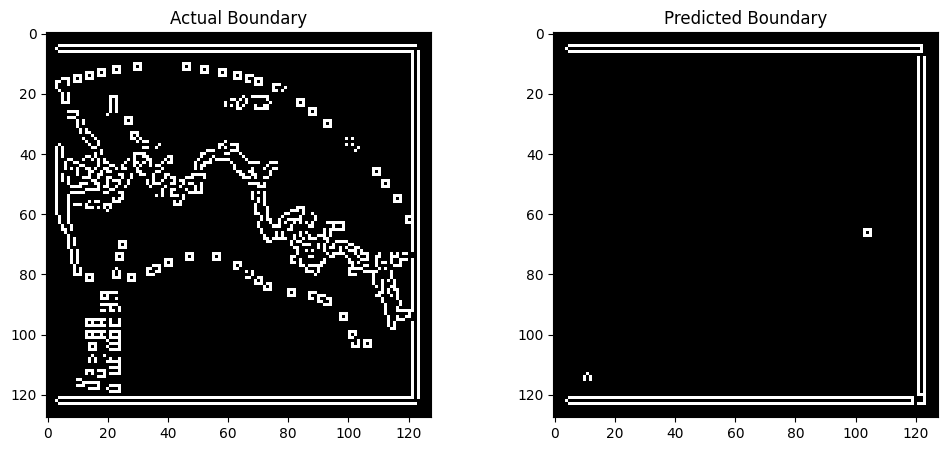

In [53]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Actual Boundary")
plt.imshow(extract_edges(true_classes[0]), cmap='gray')

plt.subplot(1,2,2)
plt.title("Predicted Boundary")
plt.imshow(extract_edges(pred_classes[0]), cmap='gray')

plt.show()

In [73]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.cluster import KMeans
from tensorflow.keras.layers import ConvLSTM2D, Conv2D, Input, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization
from tensorflow.keras.models import Model

# --- CONFIG ---
IMG_SIZE = (128, 128)
SEQ_LENGTH = 2
NUM_CLASSES = 5
DATASET_PATH = "flood_dataset/"

def load_data(folder):
    images = []
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        images.append(img / 255.0)
    return np.array(images)

# 1. Load and Augment (9 images total)
raw_images = load_data(DATASET_PATH)
aug_images = np.concatenate([raw_images, np.flip(raw_images, axis=2)], axis=0)

# 2. Convert Colors to Classes (Segmentation Mask L)
pixels = aug_images.reshape(-1, 3)
kmeans = KMeans(n_clusters=NUM_CLASSES, n_init=10, random_state=42).fit(pixels)
labels = kmeans.predict(pixels).reshape(-1, *IMG_SIZE)

# 3. Create Sequences for ConvLSTM
X_seq, y_seq = [], []
for i in range(len(aug_images) - SEQ_LENGTH):
    X_seq.append(aug_images[i : i + SEQ_LENGTH])
    y_seq.append(tf.keras.utils.to_categorical(labels[i + SEQ_LENGTH], NUM_CLASSES))

X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# 4. Model Architecture (U-Net + ConvLSTM)
inputs = Input(shape=(SEQ_LENGTH, 128, 128, 3))
x = ConvLSTM2D(32, (3,3), padding='same', return_sequences=False, activation='relu')(inputs)
x = BatchNormalization()(x)

c1 = Conv2D(64, (3,3), activation='relu', padding='same')(x)
p1 = MaxPooling2D((2,2))(c1)
c2 = Conv2D(128, (3,3), activation='relu', padding='same')(p1)
u1 = UpSampling2D((2,2))(c2)
merge = Concatenate()([u1, c1])
outputs = Conv2D(NUM_CLASSES, (1,1), activation='softmax')(merge)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_seq, y_seq, epochs=100, batch_size=2, verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.8047 - loss: 0.8624
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9019 - loss: 0.3995
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9029 - loss: 0.3398
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9125 - loss: 0.3189
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9241 - loss: 0.3059
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9261 - loss: 0.2760
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9267 - loss: 0.2697
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9255 - loss: 0.2778
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9281 - loss: 0.2701
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9271 - loss: 0.2744
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9290 - loss: 0.2567
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy:

In [75]:
def apply_math_boundary(label_map):
    """
    Implements: B(x,y) = 1 if L(x,y) != L(x+1,y) OR L(x,y) != L(x,y+1)
    """
    h, w = label_map.shape
    boundary = np.zeros((h, w), dtype=np.uint8)

    # Vectorized neighbor comparison (Shift and Compare)
    # Check horizontal neighbors: L(x,y) != L(x, y+1)
    diff_h = label_map[:, :-1] != label_map[:, 1:]
    # Check vertical neighbors: L(x,y) != L(x+1, y)
    diff_v = label_map[:-1, :] != label_map[1:, :]

    # Apply to boundary map (padding to maintain original size)
    boundary[:, :-1] |= diff_h.astype(np.uint8)
    boundary[:-1, :] |= diff_v.astype(np.uint8)

    return boundary * 255 # Convert 1 to 255 for White/Black visual

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


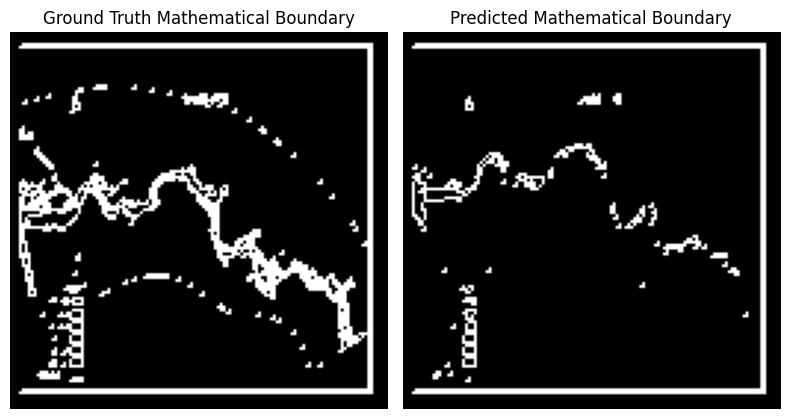

In [77]:
import random

# Pick random sequence
idx = random.randint(0, len(X_seq) - 1)
test_input = X_seq[idx:idx+1]

# 1. Get Predicted Probability Map -> Argmax to get Class Labels (L)
prediction = model.predict(test_input)
L_predicted = np.argmax(prediction[0], axis=-1)

# 2. Get Ground Truth Labels (L) for comparison
L_actual = np.argmax(y_seq[idx], axis=-1)

# 3. Apply your Mathematical Formula
sharp_boundary_pred = apply_math_boundary(L_predicted)
sharp_boundary_true = apply_math_boundary(L_actual)

# --- VISUALIZE ---
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.title("Ground Truth Mathematical Boundary")
plt.imshow(sharp_boundary_true, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Predicted Mathematical Boundary")
plt.imshow(sharp_boundary_pred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


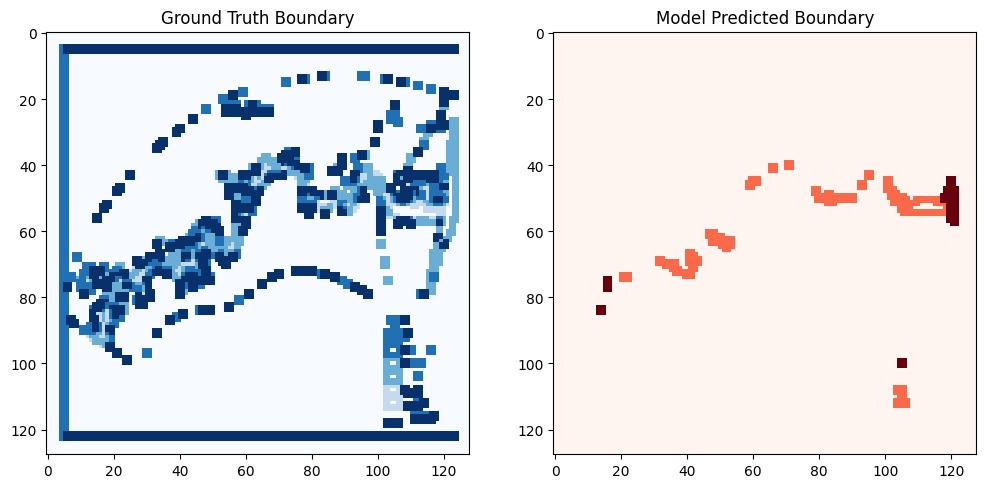

In [63]:
def get_sharp_boundary(mask):
    # Use morphological gradient to find the exact line where classes change
    kernel = np.ones((3,3), np.uint8)
    return cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)

# Predict on the first sequence
pred = model.predict(X_seq[:1])
pred_mask = np.argmax(pred[0], axis=-1)
true_mask = np.argmax(y_categorical[0], axis=-1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Ground Truth Boundary")
plt.imshow(get_sharp_boundary(true_mask), cmap='Blues')

plt.subplot(1, 2, 2)
plt.title("Model Predicted Boundary")
plt.imshow(get_sharp_boundary(pred_mask), cmap='Reds')
plt.show()

X shape: (102, 2, 128, 128, 3)
y shape: (102, 128, 128, 5)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 128, 128,  │     40,448 │ input_layer[0][0] │
│ (ConvLSTM2D)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │        325 │ conv2d_6[0][0]  

 Total params: 1,166,085 (4.45 MB)

 Trainable params: 1,166,021 (4.45 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 289ms/step - accuracy: 0.9003 - loss: 0.3438
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.9282 - loss: 0.2224
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step - accuracy: 0.9308 - loss: 0.2126
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 309ms/step - accuracy: 0.9322 - loss: 0.2093
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 309ms/step - accuracy: 0.9321 - loss: 0.2063
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 326ms/step - accuracy: 0.9326 - loss: 0.2088
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 348ms/step - accuracy: 0.9345 - loss: 0.2026
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 354ms/step - accuracy: 0.9340 - loss: 0.1981
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 364ms/step - accuracy: 0.9356 - loss: 0.1923
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 402ms/step - accuracy: 0.9384 - loss: 0.1889
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step - accuracy: 0.9396 - loss: 0.1870
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 23

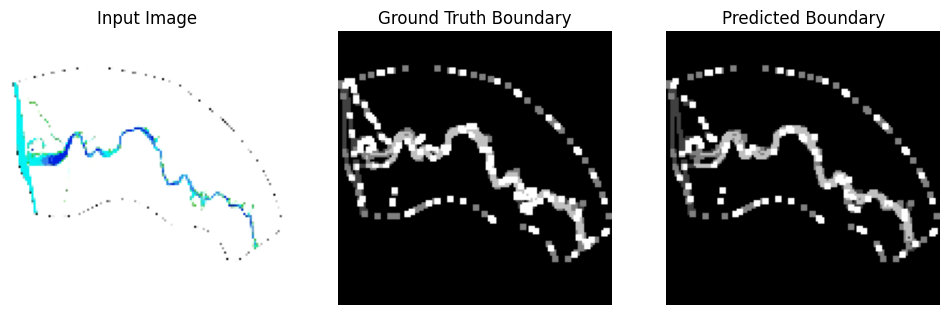

In [1]:
import numpy as np
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# ------------------ CONFIG ------------------
IMG_SIZE = (128, 128)
SEQ_LENGTH = 2
NUM_CLASSES = 5
DATASET_PATH = "flood_dataset/"

# ------------------ LOAD DATA ------------------
def load_images(folder):
    images = []
    files = sorted([f for f in os.listdir(folder) if f.endswith(('.png','.jpg','.jpeg'))])

    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        images.append(img / 255.0)

    return np.array(images)

images = load_images(DATASET_PATH)

# ------------------ AUGMENTATION ------------------
images = np.concatenate([images, np.flip(images, axis=2)], axis=0)

# ------------------ KMEANS LABEL GENERATION ------------------
pixels = images.reshape(-1, 3)

kmeans = KMeans(n_clusters=NUM_CLASSES, n_init=10, random_state=42)
kmeans.fit(pixels)

labels = kmeans.predict(pixels)
labels = labels.reshape(len(images), IMG_SIZE[0], IMG_SIZE[1])

# ------------------ CREATE SEQUENCES ------------------
X_seq, y_seq = [], []

for i in range(len(images) - SEQ_LENGTH):
    X_seq.append(images[i:i+SEQ_LENGTH])
    y_seq.append(tf.keras.utils.to_categorical(labels[i+SEQ_LENGTH], NUM_CLASSES))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

# ------------------ MODEL (UNET + CONVLSTM) ------------------

inputs = Input(shape=(SEQ_LENGTH, 128, 128, 3))

# ConvLSTM Encoder
x = ConvLSTM2D(32, (3,3), padding='same', return_sequences=False, activation='relu')(inputs)
x = BatchNormalization()(x)

# Encoder
c1 = Conv2D(64, (3,3), activation='relu', padding='same')(x)
c1 = Conv2D(64, (3,3), activation='relu', padding='same')(c1)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(128, (3,3), activation='relu', padding='same')(p1)
c2 = Conv2D(128, (3,3), activation='relu', padding='same')(c2)
p2 = MaxPooling2D((2,2))(c2)

# Bottleneck
b = Conv2D(256, (3,3), activation='relu', padding='same')(p2)

# Decoder
u1 = UpSampling2D((2,2))(b)
u1 = Concatenate()([u1, c2])
c3 = Conv2D(128, (3,3), activation='relu', padding='same')(u1)

u2 = UpSampling2D((2,2))(c3)
u2 = Concatenate()([u2, c1])
c4 = Conv2D(64, (3,3), activation='relu', padding='same')(u2)

# Output
outputs = Conv2D(NUM_CLASSES, (1,1), activation='softmax')(c4)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# ------------------ TRAIN ------------------
model.fit(X_seq, y_seq, epochs=50, batch_size=2)

# ------------------ BOUNDARY FUNCTION ------------------
def get_boundary(mask):
    kernel = np.ones((3,3), np.uint8)
    return cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)

# ------------------ TEST ------------------
import random

idx = random.randint(0, len(X_seq)-1)
test_input = X_seq[idx:idx+1]

pred = model.predict(test_input)
pred_mask = np.argmax(pred[0], axis=-1)
true_mask = np.argmax(y_seq[idx], axis=-1)

# ------------------ VISUALIZATION ------------------
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(test_input[0][-1])
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Boundary")
plt.imshow(get_boundary(true_mask), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Boundary")
plt.imshow(get_boundary(pred_mask), cmap='gray')
plt.axis('off')

plt.show()